In [1]:
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering, Rotations, ImageTransformations, CoordinateTransformations
using Statistics

In [2]:
function smooth_imgs(img, size_kernel)
    """ Smooth the images with a flat kernel to find the stripes more easily """
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    """ Normalize the images to use the same threshold for all the pictures in a dataset """
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_stripe_radius_range(img, stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes)
    """ Finds the center and major/minor axis of each stripes on a given picture """
    blob_centers, major_axis_blobs, minor_axis_blobs = [], [], []
    response = zeros(size(img))
    

    for i in 1:length(stripe_major_axis_range)
        for j in 1:length(stripe_minor_axis_range)
            log_kernel = Kernel.gaussian((stripe_minor_axis_range[j], stripe_major_axis_range[i]))

            response .+= imfilter(img, log_kernel) .* stripe_minor_axis_range[j]*stripe_major_axis_range[i]
        end
    end

    blobs = response .> threshold_stripes * std(img) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)

        if (length(inds) < 2e3) & (maximum([maximum([i[1]-1 for i in inds]) - minimum([i[1]-1 for i in inds])]) < 15) # If blob detected is too big, we do not count it (couldn't find angle of stripes/two stripes overlap)
            push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
            push!(major_axis_blobs, maximum([i[2]-1 for i in inds]) - minimum([i[2]-1 for i in inds]))
            push!(minor_axis_blobs, maximum([i[1]-1 for i in inds]) - minimum([i[1]-1 for i in inds]))
        end
    end

    return blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs
end


function mask_ellipse(xc, yc, a, b, θ, width, height)
    """ Mask of size (width, height) of an ellipse rotated by an angle θ, centered on [xc, yc], with major/minor axis a/b"""
    mask = zeros(Integer, (width, height))
    X = range(0, height-1) .- yc
    Y = range(0, width-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function rot_img(img, θ)
    """ Rotate an image with an angle θ, padd with 0 """
    trfm = recenter(RotMatrix(θ), center(img))
    imgw = parent(warp(img, trfm))
    imgw[isnan.(imgw)] .= 0 # Padd the NaN values to 0
    return imgw
end

function rotate_img_stripe_angle(img)
    """ Finds the angle at which the stripes are along the horizontal axis,
    ie where a sum along the horizontal axis is maximal """
    θ_range = [0:0.1:π/2;]

    Maximum_hor_mean = zeros(length(θ_range))

    for (i, θ) in enumerate(θ_range)
        imgw = rot_img(img, θ)

        Maximum_hor_mean[i] = maximum(sum(imgw, dims=2))
    end
    return θ_range[argmax(Maximum_hor_mean)]
end

function find_rotate_angle_stripes(img)
    """ Find the angle of the stripes and return the image rotated by this angle 
    so that the stripes are along the horizontal axis, and the angle as a 2nd argument """
    θ = rotate_img_stripe_angle(img)
    return rot_img(img, θ), θ
end

find_rotate_angle_stripes (generic function with 1 method)

### Load the images/ODs

In [3]:
# pathdir = "Y:/TwoDGas/2026/02/06/0000" # Stripes 60°
pathdir = "Y:/StructuralPhaseTransition/2026/02/11/0001" # Stripes 90°


@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset
nbr_amp_laser = length(unique(Amplitude_laser))

# Stripe parameters
size_kernel_smooth = 5
stripe_major_axis_range = [5:1:20;]
stripe_minor_axis_range = [1:1:2;];

### Find the thresholds

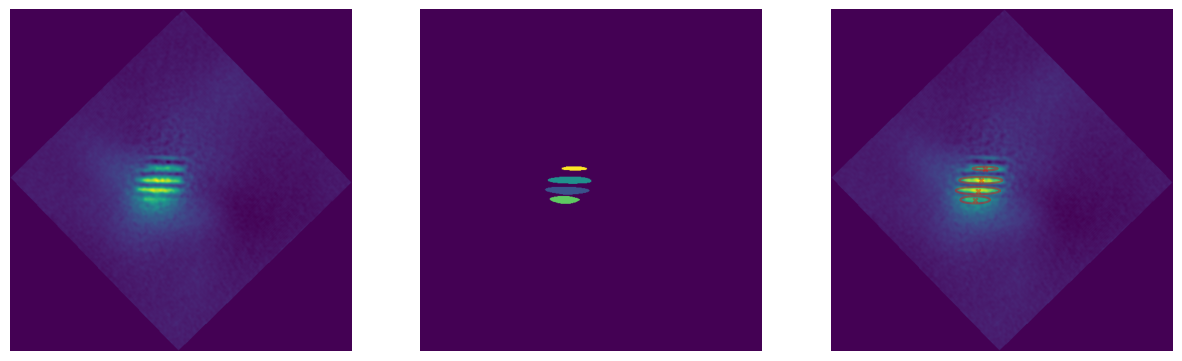

In [4]:
i, j = 18, 1

# threshold_stripes = [5000, 2000, 2500, 2600, 2600, 2700, 2800, 2800, 3000, 3000,
#                         3100, 3100, 3100, 3100, 3100, 3100, 3200, 3300, 3400] # Y:/TwoDGas/2026/02/06/0000 Stripes 60°

threshold_stripes = [5000, 2100, 2600, 2700, 2800, 2900, 2900, 2900, 3100, 3100,
                3200, 3200, 3200, 3200, 3200, 3200, 3300, 3400, 3500] # Y:/StructuralPhaseTransition/2026/02/11/0001 Stripes 90°

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]
smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
img_rot, θ = find_rotate_angle_stripes(smooth_norm_OD)

axs[1].imshow(img_rot)

# Find the stripes
blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(float.(img_rot), stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])

axs[2].imshow(label_blobs)

axs[3].imshow(img_rot)

# Draw ellipse for each detected stripe
θ_range = [0:0.01:2π;]
for (i, c) in enumerate(blob_centers)
    axs[3].scatter(c[1], c[2], s=10, marker="x", color="r", alpha=0.4)
    axs[3].plot((major_axis_blobs[i]/2 .*cos.(θ_range)).+c[1], (minor_axis_blobs[i]/2 .*sin.(θ_range)).+c[2], color="r", alpha=0.4)
end

for ax in axs
    ax.axis("off")
end

pygui(false);
# pygui(true); show();

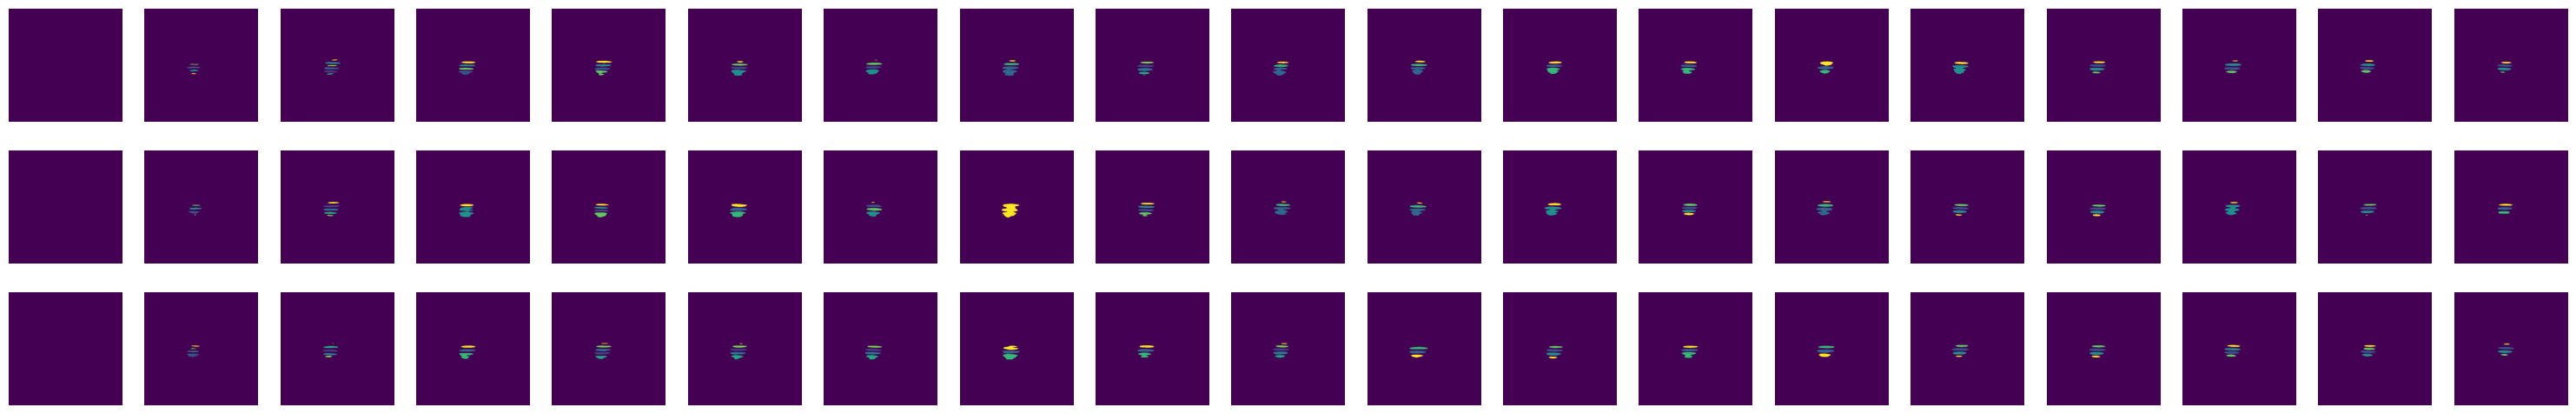

In [5]:
nbr_img_per_sat = 3

close("all")
fig, axs = subplots(nbr_img_per_sat, nbr_amp_laser, figsize=(2*nbr_amp_laser, 2*nbr_img_per_sat))

for i in 1:nbr_amp_laser
    for j = 1:nbr_img_per_sat
        OD = ODs_dataset[i, j, :, :]
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Smooth with flat kernel + normalize
        img_rot, θ = find_rotate_angle_stripes(smooth_norm_OD)

        if (θ > π/6) & (θ < π/3) # To be considered valid, the normalized smoothed images should have a minimum contrast, and the angle of the stripes should be between π/3 > θ > π/6
            blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(img_rot, stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])
            axs[j, i].imshow(label_blobs)
        end

        for ax in axs
            ax.axis("off")
        end
    end
end

# axis("off")
pygui(false);

# Find the stripes

In [6]:
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes")
end

"Images/2026_02_11_0001/Stripes"

In [7]:
nbr_stripes_ds = zeros(size(ODs_dataset)[1:2])
centers_stripes_ds, major_axis_stripes_ds, minor_axis_stripes_ds = [], [], []
save_imgs = true
θ_range = [0:0.01:2π;]

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for i in ProgressBar(1:nbr_amp_laser)
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(unique(Amplitude_laser)[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(unique(Amplitude_laser)[i])")
    end

    centers_stripes, major_axis_stripes, minor_axis_stripes =  [], [], []

    for j = 1:size(ODs_dataset)[2]
        OD = ODs_dataset[i, j, :, :]
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Smooth with flat kernel + normalize
        img_rot, θ = find_rotate_angle_stripes(smooth_norm_OD)
        
        if  (θ > π/6)  & (θ < π/3) # To be considered valid, the normalized smoothed images should have a minimum contrast, and the angle of the stripes should be between π/3 > θ > π/6
            blob_centers, major_axis_blobs, minor_axis_blobs, label_blobs = find_stripe_radius_range(img_rot, stripe_major_axis_range, stripe_minor_axis_range, threshold_stripes[i])

            if save_imgs
                axs[1].imshow(img_rot)
                axs[2].imshow(label_blobs)
                axs[3].imshow(img_rot)
                axs[3].scatter([c[1] for c in blob_centers], [c[2] for c in blob_centers], s=10, marker="x", color="r", alpha=0.5)

                # Draw ellipse for each detected stripe
                for (i, c) in enumerate(blob_centers)
                    axs[3].scatter(c[1], c[2], s=10, marker="x", color="r", alpha=0.4)
                    axs[3].plot((major_axis_blobs[i] /2 .*cos.(θ_range)).+c[1], (minor_axis_blobs[i] /2 .*sin.(θ_range)).+c[2], color="r", alpha=0.4)
                end

                savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Stripes/$(unique(Amplitude_laser)[i])/$(j-1).png")
                for ax in axs
                    ax.clear()
                end
            end

            nbr_stripes_ds[i, j] = length(blob_centers)
        end
        push!(centers_stripes, blob_centers), push!(major_axis_stripes, major_axis_blobs), push!(minor_axis_stripes, minor_axis_blobs)
    end
    push!(centers_stripes_ds, centers_stripes), push!(major_axis_stripes_ds, major_axis_stripes), push!(minor_axis_stripes_ds, minor_axis_stripes)
end

close("all")

0.0%┣                                               ┫ 0/19 [00:06<-2:-2, -6s/it]
5.3%┣██▎                                        ┫ 1/19 [00:50<Inf:Inf, InfGs/it]
10.5%┣████▉                                         ┫ 2/19 [01:26<24:26, 86s/it]
15.8%┣███████▎                                      ┫ 3/19 [01:58<15:44, 59s/it]
21.1%┣█████████▊                                    ┫ 4/19 [02:28<12:21, 49s/it]
26.3%┣████████████                                  ┫ 5/19 [02:59<10:26, 45s/it]
31.6%┣██████████████▌                               ┫ 6/19 [03:29<09:02, 42s/it]
36.8%┣█████████████████                             ┫ 7/19 [03:58<07:56, 40s/it]
42.1%┣███████████████████▍                          ┫ 8/19 [04:26<06:58, 38s/it]
47.4%┣█████████████████████▉                        ┫ 9/19 [04:55<06:08, 37s/it]
52.6%┣███████████████████████▊                     ┫ 10/19 [05:24<05:24, 36s/it]
57.9%┣██████████████████████████                   ┫ 11/19 [05:53<04:43, 35s/it]
63.2%┣██████████████████████

In [8]:
@save "Saved_exp_data/Stripes_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_stripes_ds major_axis_stripes_ds minor_axis_stripes_ds nbr_stripes_ds

### Brouillons

In [9]:
# fig, axs = subplots(1, 2, figsize=(10, 5))

# stripe_major_axis_range = [10:5:20;]
# stripe_minor_axis_range = [2:1:5;];

# axs[1].imshow(imgw)
# axs[2].imshow(Kernel.gaussian((stripe_minor_axis_range[1], stripe_major_axis_range[1])))
# pygui(true); show()